In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path


In [2]:
# Path of the dataset

BASE_DIR=Path.cwd().parent.parent


DATA_PATH=(
    BASE_DIR
    /"data"
    /"raw"
    /"paysim.csv"
)

# Part of the r 
REPORT_DIR=Path.cwd().parent.parent/"reports"/"figures"

df=pd.read_csv(DATA_PATH)

In [3]:
df = pd.read_csv(DATA_PATH)

In [4]:
df["origBalanceDiff"]=(
    df["oldbalanceOrg"]
    -df["newbalanceOrig"]
)

In [5]:
df=pd.get_dummies(
    df,
    columns=["type"],
    drop_first=True
)

In [6]:
df = df.drop(
    columns=["nameOrig", "nameDest"]
)

In [7]:
df=df.drop(
    columns=["isFlaggedFraud"]
)

In [8]:
X=df.drop("isFraud", axis=1)

y=df["isFraud"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
negative=y_train.value_counts()[0]

positive=y_train.value_counts()[1]

scale_pos_weight=negative/positive

print(scale_pos_weight)

773.7482496194825


In [11]:
from xgboost import XGBClassifier

xgb_model=XGBClassifier(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

In [12]:
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [13]:
y_pred=xgb_model.predict(X_test)

y_probs=xgb_model.predict_proba(X_test)[:,1]

In [14]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test, y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.64      0.97      0.77      1643

    accuracy                           1.00   1272524
   macro avg       0.82      0.98      0.88   1272524
weighted avg       1.00      1.00      1.00   1272524



In [15]:
from sklearn.metrics import roc_auc_score

roc_auc=roc_auc_score(
    y_test,
    y_probs
)

print("ROC-AUC", roc_auc)

ROC-AUC 0.9998357324916615


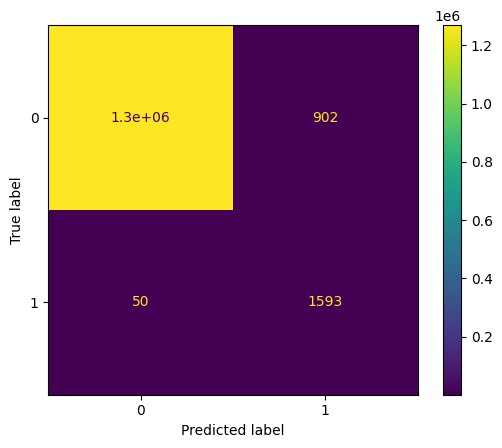

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [17]:
importance=pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
    
)

top_features=importance.sort_values(
    ascending=False
).head(10)

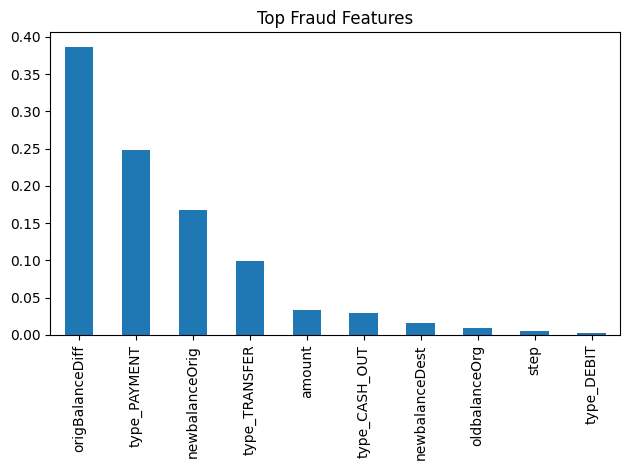

In [18]:
top_features.plot(kind="bar")

plt.title("Top Fraud Features")

plt.tight_layout()

PLOT_DIR=REPORT_DIR/"Top Fraud Features.png"

plt.savefig(PLOT_DIR)

plt.show()

In [19]:
from sklearn.metrics import classification_report

thresholds = [
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9
]

for threshold in thresholds:

    y_pred_threshold = (
        y_probs > threshold
    ).astype(int)

    print(f"\nThreshold: {threshold}")

    print(
        classification_report(
            y_test,
            y_pred_threshold
        )
    )


Threshold: 0.1
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.44      0.99      0.61      1643

    accuracy                           1.00   1272524
   macro avg       0.72      0.99      0.80   1272524
weighted avg       1.00      1.00      1.00   1272524


Threshold: 0.2
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.51      0.99      0.67      1643

    accuracy                           1.00   1272524
   macro avg       0.75      0.99      0.84   1272524
weighted avg       1.00      1.00      1.00   1272524


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.56      0.98      0.72      1643

    accuracy                           1.00   1272524
   macro avg       0.78      0.99      0.86   1272524
weighted avg       1.00   

In [20]:
print(BASE_DIR)

/home/afrozdebian/coding/fraud_detection


In [23]:
import joblib

MODEL_PATH=BASE_DIR/"models"/"paysim"/"xgboost_paysim_model.joblib"

joblib.dump(
    xgb_model,
    MODEL_PATH
)

['/home/afrozdebian/coding/fraud_detection/models/paysim/xgboost_paysim_model.joblib']

In [25]:
import json 
config={
    "threshold":0.9
}

with open(BASE_DIR/"models"/"paysim"/"config.json", "w") as f:
    json.dump(config, f, indent=4)

In [26]:
metrics={
    "precision":0.92,
    "recall":0.94,
    "f1_score":0.87,
    "threshold":0.90
}

with open(BASE_DIR/"models"/"paysim"/"metrics.json", "w") as f:
    json.dump(config, f, indent=4)

In [27]:
from sklearn.metrics import f1_score

best_threshold = 0
best_f1 = 0

for threshold in thresholds:

    preds = (y_probs > threshold).astype(int)

    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(best_threshold)
print(best_f1)

0.9
0.8737644733126235
